# NetworkX Benchmark Notebook
### Sparse vs Dense Graphs — Performance, Diagnosis, and Acceleration

This notebook walks through four phases:
1. **Baseline** — built-in social graphs, timing core algorithms
2. **Synthetic ladder** — controlled density with four graph generators
3. **SNAP datasets** — real-world large-scale graphs
4. **Acceleration** — sparse matrices, approximation, igraph comparison


## Setup — Installs & Imports

In [1]:
# Run once — install everything needed
import subprocess, sys
pkgs = ["networkx", "scipy", "matplotlib", "numpy", "pandas", "python-igraph", "joblib"]
subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet"] + pkgs)
print("All packages ready.")

All packages ready.


In [2]:
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import networkx as nx
from contextlib import contextmanager

warnings.filterwarnings("ignore")
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
})

@contextmanager
def timer(label=""):
    """Context manager that prints and returns elapsed time in ms."""
    t0 = time.perf_counter()
    yield
    elapsed = (time.perf_counter() - t0) * 1000
    print(f"  {label:<45} {elapsed:>8.2f} ms")
    return elapsed

def time_algo(func, *args, **kwargs):
    """Run a function and return (result, elapsed_ms)."""
    t0 = time.perf_counter()
    result = func(*args, **kwargs)
    return result, (time.perf_counter() - t0) * 1000

def graph_summary(G, name="G"):
    """Print a one-line summary of a graph."""
    print(f"  {name}: {G.number_of_nodes():>6,} nodes  {G.number_of_edges():>8,} edges  density={nx.density(G):.5f}")

print("Imports complete.")

Imports complete.


---
## Phase 1 — Baseline: Built-in Social Graphs

We time four standard NetworkX algorithms across the four bundled social graphs.
These are small graphs — the goal is to establish a clear timing baseline and show
that *even at small scale*, algorithm complexity varies dramatically with density.

| Algorithm | Complexity | Notes |
|---|---|---|
| `betweenness_centrality` | O(VE) | Heaviest — best discriminator |
| `clustering` | O(degree²) per node | Sensitive to local density |
| `shortest_path_length` | O(V+E) | BFS from node 0 |
| `is_connected` | O(V+E) | Cheapest — structural only |


In [3]:
# ── Load all four built-in graphs ──────────────────────────────────────────
graphs = {
    "Karate Club":          nx.karate_club_graph(),
    "Florentine Families":  nx.florentine_families_graph(),
    "Davis Women":          nx.davis_southern_women_graph(),
    "Les Misérables":       nx.les_miserables_graph(),
}

print("Graph summaries:")
for name, G in graphs.items():
    graph_summary(G, name)

Graph summaries:
  Karate Club:     34 nodes        78 edges  density=0.13904
  Florentine Families:     15 nodes        20 edges  density=0.19048
  Davis Women:     32 nodes        89 edges  density=0.17944
  Les Misérables:     77 nodes       254 edges  density=0.08681


In [4]:
# ── Time each algorithm on each graph ──────────────────────────────────────
algorithms = {
    "betweenness_centrality": lambda G: nx.betweenness_centrality(G),
    "clustering":             lambda G: nx.clustering(G),
    "shortest_path_length":   lambda G: dict(nx.single_source_shortest_path_length(G, list(G.nodes)[0])),
    "is_connected":           lambda G: nx.is_connected(G),
}

records = []
for gname, G in graphs.items():
    for aname, algo in algorithms.items():
        _, ms = time_algo(algo, G)
        records.append({
            "graph":     gname,
            "algorithm": aname,
            "nodes":     G.number_of_nodes(),
            "edges":     G.number_of_edges(),
            "density":   nx.density(G),
            "time_ms":   ms,
        })

df_baseline = pd.DataFrame(records)
print(df_baseline.pivot(index="graph", columns="algorithm", values="time_ms").round(3).to_string())

algorithm            betweenness_centrality  clustering  is_connected  shortest_path_length
graph                                                                                      
Davis Women                           2.600       0.424         0.023                 0.028
Florentine Families                   0.444       0.133         0.014                 0.019
Karate Club                           3.370       1.337         0.355                 0.318
Les Misérables                       12.134       1.324         0.047                 0.190


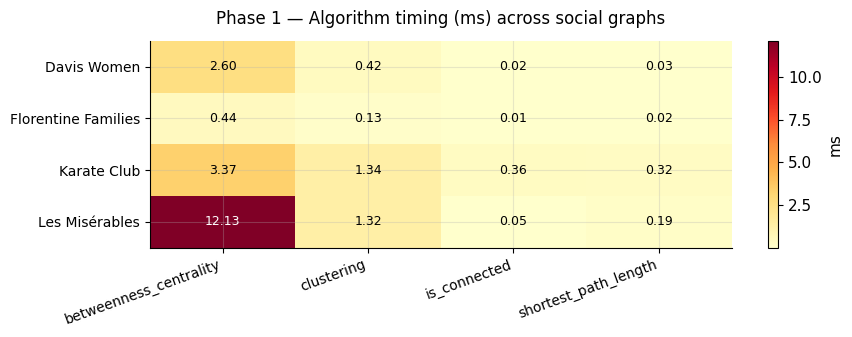

Key insight: betweenness_centrality dominates — O(VE) cost visible even at <100 nodes.


In [5]:
# ── Visualise — heatmap of timing (ms) ──────────────────────────────────────
pivot = df_baseline.pivot(index="graph", columns="algorithm", values="time_ms")

fig, ax = plt.subplots(figsize=(9, 3.5))
im = ax.imshow(pivot.values, aspect="auto", cmap="YlOrRd")
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns, rotation=20, ha="right", fontsize=10)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index, fontsize=10)
ax.set_title("Phase 1 — Algorithm timing (ms) across social graphs", fontsize=12, pad=12)
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        ax.text(j, i, f"{pivot.values[i,j]:.2f}", ha="center", va="center", fontsize=9,
                color="white" if pivot.values[i,j] > pivot.values.max()*0.6 else "black")
plt.colorbar(im, ax=ax, label="ms")
plt.tight_layout()
plt.savefig("phase1_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Key insight: betweenness_centrality dominates — O(VE) cost visible even at <100 nodes.")

---
## Phase 2 — Synthetic Density Ladder

Four generators, each run at multiple density settings with N held constant.
This isolates *density* as the independent variable and shows how each algorithm
responds to edge count growth.


### 2a — Erdős–Rényi: pure edge-count effect

In [6]:
# ── Erdős–Rényi across a range of p values ──────────────────────────────────
N = 800
p_values = [0.01, 0.03, 0.06, 0.10, 0.20, 0.35]

er_records = []
print(f"Erdős–Rényi n={N}, varying p:")
for p in p_values:
    G = nx.erdos_renyi_graph(n=N, p=p, seed=42)
    d = nx.density(G)
    _, t_bc  = time_algo(nx.betweenness_centrality, G)
    _, t_cl  = time_algo(nx.clustering, G)
    er_records.append(dict(p=p, density=d, edges=G.number_of_edges(),
                           betweenness_ms=t_bc, clustering_ms=t_cl))
    print(f"  p={p:.2f}  edges={G.number_of_edges():>6,}  density={d:.4f}  "
          f"betweenness={t_bc:6.1f}ms  clustering={t_cl:5.1f}ms")

df_er = pd.DataFrame(er_records)

Erdős–Rényi n=800, varying p:
  p=0.01  edges= 3,229  density=0.0101  betweenness=1897.1ms  clustering= 16.8ms
  p=0.03  edges= 9,453  density=0.0296  betweenness=3416.4ms  clustering= 84.1ms
  p=0.06  edges=19,038  density=0.0596  betweenness=4169.2ms  clustering=249.6ms
  p=0.10  edges=31,982  density=0.1001  betweenness=7495.9ms  clustering=740.0ms
  p=0.20  edges=64,065  density=0.2005  betweenness=12642.8ms  clustering=2533.6ms
  p=0.35  edges=111,692  density=0.3495  betweenness=24362.0ms  clustering=7010.7ms


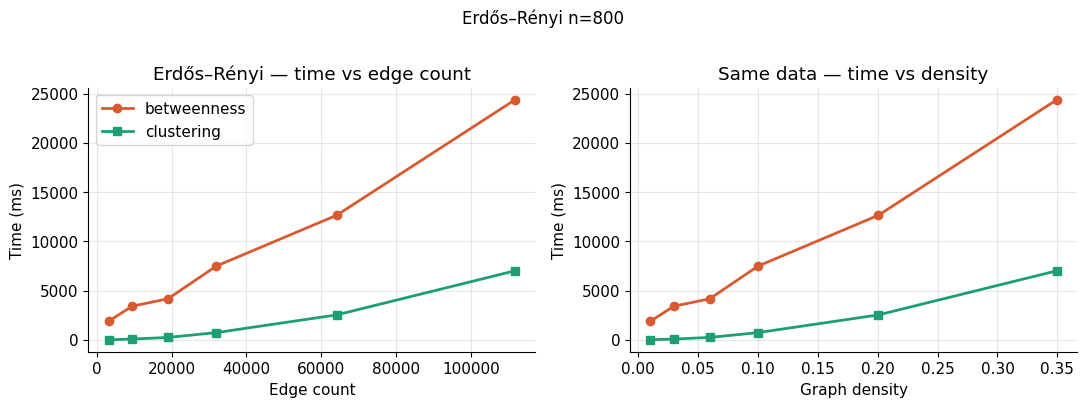

In [7]:
# ── Plot Erdős–Rényi timing curves ──────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

ax1.plot(df_er["edges"], df_er["betweenness_ms"], "o-", color="#D85A30", lw=2, label="betweenness")
ax1.plot(df_er["edges"], df_er["clustering_ms"],  "s-", color="#1D9E75", lw=2, label="clustering")
ax1.set_xlabel("Edge count"); ax1.set_ylabel("Time (ms)")
ax1.set_title("Erdős–Rényi — time vs edge count"); ax1.legend()

ax2.plot(df_er["density"], df_er["betweenness_ms"], "o-", color="#D85A30", lw=2)
ax2.plot(df_er["density"], df_er["clustering_ms"],  "s-", color="#1D9E75", lw=2)
ax2.set_xlabel("Graph density"); ax2.set_ylabel("Time (ms)")
ax2.set_title("Same data — time vs density")

plt.suptitle(f"Erdős–Rényi n={N}", fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig("phase2a_er.png", dpi=150, bbox_inches="tight")
plt.show()

### 2b — Stochastic Block Model: community bleed effect

In [8]:
# ── SBM: tight vs leaky communities ─────────────────────────────────────────
sizes = [120, 120, 120]

configs = {
    "sparse (tight)":  [[0.80, 0.01, 0.01],
                        [0.01, 0.80, 0.01],
                        [0.01, 0.01, 0.80]],
    "medium":          [[0.80, 0.20, 0.20],
                        [0.20, 0.80, 0.20],
                        [0.20, 0.20, 0.80]],
    "dense (leaky)":   [[0.80, 0.50, 0.50],
                        [0.50, 0.80, 0.50],
                        [0.50, 0.50, 0.80]],
}

sbm_records = []
print("Stochastic Block Model (3 blocks × 120 nodes each):")
for label, probs in configs.items():
    G = nx.stochastic_block_model(sizes, probs, seed=42)
    d = nx.density(G)
    _, t_bc = time_algo(nx.betweenness_centrality, G)
    _, t_cl = time_algo(nx.clustering, G)
    _, t_lp = time_algo(nx.community.louvain_communities, G)  # community detection cost
    sbm_records.append(dict(label=label, density=d, edges=G.number_of_edges(),
                            betweenness_ms=t_bc, clustering_ms=t_cl, louvain_ms=t_lp))
    print(f"  {label:<20} edges={G.number_of_edges():>5,}  density={d:.4f}  "
          f"betweenness={t_bc:6.1f}ms  louvain={t_lp:5.1f}ms")

df_sbm = pd.DataFrame(sbm_records)

Stochastic Block Model (3 blocks × 120 nodes each):
  sparse (tight)       edges=17,567  density=0.2719  betweenness=1388.6ms  louvain=110.6ms
  medium               edges=25,769  density=0.3988  betweenness=2235.6ms  louvain=262.5ms
  dense (leaky)        edges=38,847  density=0.6012  betweenness=3584.9ms  louvain=278.9ms


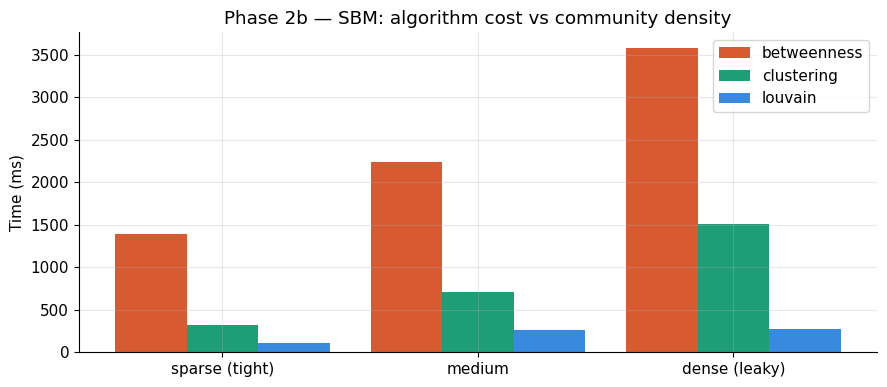

Key insight: cross-block density inflates betweenness dramatically — bridges become expensive.


In [9]:
# ── Bar chart comparing SBM configs ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(df_sbm))
w = 0.28
ax.bar(x - w, df_sbm["betweenness_ms"], w, label="betweenness", color="#D85A30")
ax.bar(x,     df_sbm["clustering_ms"],  w, label="clustering",  color="#1D9E75")
ax.bar(x + w, df_sbm["louvain_ms"],     w, label="louvain",     color="#378ADD")
ax.set_xticks(x); ax.set_xticklabels(df_sbm["label"])
ax.set_ylabel("Time (ms)"); ax.set_title("Phase 2b — SBM: algorithm cost vs community density")
ax.legend(); plt.tight_layout()
plt.savefig("phase2b_sbm.png", dpi=150, bbox_inches="tight")
plt.show()
print("Key insight: cross-block density inflates betweenness dramatically — bridges become expensive.")

### 2c — Barabási–Albert: hub richness effect

In [10]:
# ── BA graph — m controls hub density ────────────────────────────────────────
N_ba = 2000
m_values = [1, 2, 4, 8, 15, 25]

ba_records = []
print(f"Barabási–Albert n={N_ba}, varying m:")
for m in m_values:
    G = nx.barabasi_albert_graph(n=N_ba, m=m, seed=42)
    d = nx.density(G)
    _, t_bc = time_algo(nx.betweenness_centrality, G)
    _, t_pr = time_algo(nx.pagerank, G)
    ba_records.append(dict(m=m, density=d, edges=G.number_of_edges(),
                           betweenness_ms=t_bc, pagerank_ms=t_pr))
    print(f"  m={m:>2}  edges={G.number_of_edges():>5,}  density={d:.5f}  "
          f"betweenness={t_bc:6.1f}ms  pagerank={t_pr:5.1f}ms")

df_ba = pd.DataFrame(ba_records)

Barabási–Albert n=2000, varying m:
  m= 1  edges=1,999  density=0.00100  betweenness=9002.4ms  pagerank=305.5ms
  m= 2  edges=3,996  density=0.00200  betweenness=11657.2ms  pagerank=  8.7ms
  m= 4  edges=7,984  density=0.00399  betweenness=13099.5ms  pagerank= 12.9ms
  m= 8  edges=15,936  density=0.00797  betweenness=17452.5ms  pagerank= 25.1ms
  m=15  edges=29,775  density=0.01489  betweenness=26114.5ms  pagerank= 42.4ms
  m=25  edges=49,375  density=0.02470  betweenness=34584.7ms  pagerank= 66.3ms


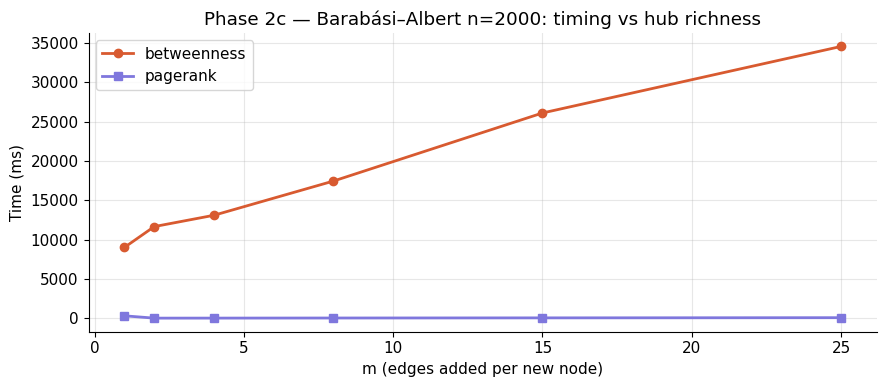

Key insight: PageRank is cheap regardless of m; betweenness explodes with hub concentration.


In [11]:
# ── BA: timing curves ────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(df_ba["m"], df_ba["betweenness_ms"], "o-", color="#D85A30", lw=2, label="betweenness")
ax.plot(df_ba["m"], df_ba["pagerank_ms"],    "s-", color="#7F77DD", lw=2, label="pagerank")
ax.set_xlabel("m (edges added per new node)"); ax.set_ylabel("Time (ms)")
ax.set_title(f"Phase 2c — Barabási–Albert n={N_ba}: timing vs hub richness"); ax.legend()
plt.tight_layout()
plt.savefig("phase2c_ba.png", dpi=150, bbox_inches="tight")
plt.show()
print("Key insight: PageRank is cheap regardless of m; betweenness explodes with hub concentration.")

### 2d — Watts–Strogatz: small-world transition

In [12]:
# ── WS graph — k=neighbours, p=rewiring ─────────────────────────────────────
N_ws = 1000
k_values = [4, 6, 10, 20, 40, 60]

ws_records = []
print(f"Watts–Strogatz n={N_ws}, p=0.1, varying k:")
for k in k_values:
    G = nx.watts_strogatz_graph(n=N_ws, k=k, p=0.1, seed=42)
    d = nx.density(G)
    avg_cl = nx.average_clustering(G)
    _, t_bc = time_algo(nx.betweenness_centrality, G)
    ws_records.append(dict(k=k, density=d, avg_clustering=avg_cl,
                           edges=G.number_of_edges(), betweenness_ms=t_bc))
    print(f"  k={k:>2}  edges={G.number_of_edges():>5,}  avg_clustering={avg_cl:.3f}  "
          f"betweenness={t_bc:6.1f}ms")

df_ws = pd.DataFrame(ws_records)

Watts–Strogatz n=1000, p=0.1, varying k:
  k= 4  edges=2,000  avg_clustering=0.388  betweenness=2391.4ms
  k= 6  edges=3,000  avg_clustering=0.452  betweenness=2658.5ms
  k=10  edges=5,000  avg_clustering=0.499  betweenness=3166.0ms
  k=20  edges=10,000  avg_clustering=0.523  betweenness=4309.5ms
  k=40  edges=20,000  avg_clustering=0.538  betweenness=8154.3ms
  k=60  edges=30,000  avg_clustering=0.544  betweenness=9745.1ms


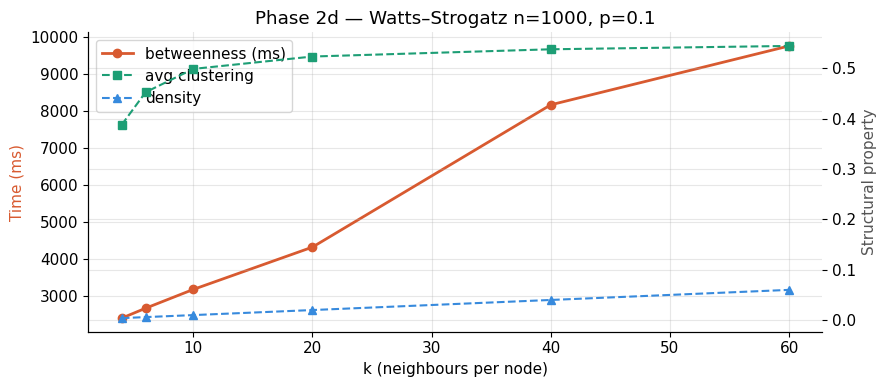

In [13]:
# ── WS: dual axis — timing vs structural properties ──────────────────────────
fig, ax1 = plt.subplots(figsize=(9, 4))
ax2 = ax1.twinx()

ax1.plot(df_ws["k"], df_ws["betweenness_ms"], "o-", color="#D85A30", lw=2, label="betweenness (ms)")
ax2.plot(df_ws["k"], df_ws["avg_clustering"], "s--", color="#1D9E75", lw=1.5, label="avg clustering")
ax2.plot(df_ws["k"], df_ws["density"],        "^--", color="#378ADD", lw=1.5, label="density")

ax1.set_xlabel("k (neighbours per node)"); ax1.set_ylabel("Time (ms)", color="#D85A30")
ax2.set_ylabel("Structural property", color="#555")
ax1.set_title(f"Phase 2d — Watts–Strogatz n={N_ws}, p=0.1")
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")
plt.tight_layout()
plt.savefig("phase2d_ws.png", dpi=150, bbox_inches="tight")
plt.show()

---
## Phase 3 — SNAP Datasets: Real-World Scale

The Facebook ego graph (4,039 nodes / 88,234 edges) is the key stress test.
Note: density ≈ 0.011 — *sparse by density*, but large by raw edge count.
This is the critical distinction: **density and scale are independent axes.**


In [3]:
import urllib.request, gzip, os

SNAP_URL  = "https://snap.stanford.edu/data/facebook_combined.txt.gz"
SNAP_FILE = "facebook.txt.gz"

if not os.path.exists(SNAP_FILE):
    print("Downloading Facebook ego graph from SNAP...")
    urllib.request.urlretrieve(SNAP_URL, SNAP_FILE)
    print("Done.")
else:
    print("Using cached file.")

with gzip.open(SNAP_FILE, "rt") as f:
    G_fb = nx.read_edgelist(f, nodetype=int)

graph_summary(G_fb, "Facebook ego")
print(f"  Is connected: {nx.is_connected(G_fb)}")
print(f"  Avg degree:   {sum(d for _, d in G_fb.degree()) / G_fb.number_of_nodes():.2f}")

Using cached file.
  Facebook ego:  4,039 nodes    88,234 edges  density=0.01082
  Is connected: True
  Avg degree:   43.69


In [4]:
# ── Time the expensive algorithms on the FB graph ────────────────────────────
print("Timing algorithms on Facebook ego graph (n=4039, e=88234)...")
print()

# Cheap algorithms first
_, t_conn = time_algo(nx.is_connected, G_fb)
print(f"  is_connected          {t_conn:.2f} ms")

_, t_cl   = time_algo(nx.average_clustering, G_fb)
print(f"  average_clustering    {t_cl:.2f} ms")

_, t_pr   = time_algo(nx.pagerank, G_fb)
print(f"  pagerank              {t_pr:.2f} ms")

_, t_bfs  = time_algo(nx.single_source_shortest_path_length, G_fb, 0)
print(f"  BFS from node 0       {t_bfs:.2f} ms")

# Betweenness — WARNING: slow on 88K edges
print()
print("  betweenness_centrality (exact) — this may take 30–120 seconds on CPU...")
_, t_bc_exact = time_algo(nx.betweenness_centrality, G_fb)
print(f"  betweenness_centrality (exact) {t_bc_exact:.0f} ms")

Timing algorithms on Facebook ego graph (n=4039, e=88234)...

  is_connected          13.14 ms
  average_clustering    2455.95 ms
  pagerank              327.52 ms
  BFS from node 0       11.68 ms

  betweenness_centrality (exact) — this may take 30–120 seconds on CPU...
  betweenness_centrality (exact) 138034 ms


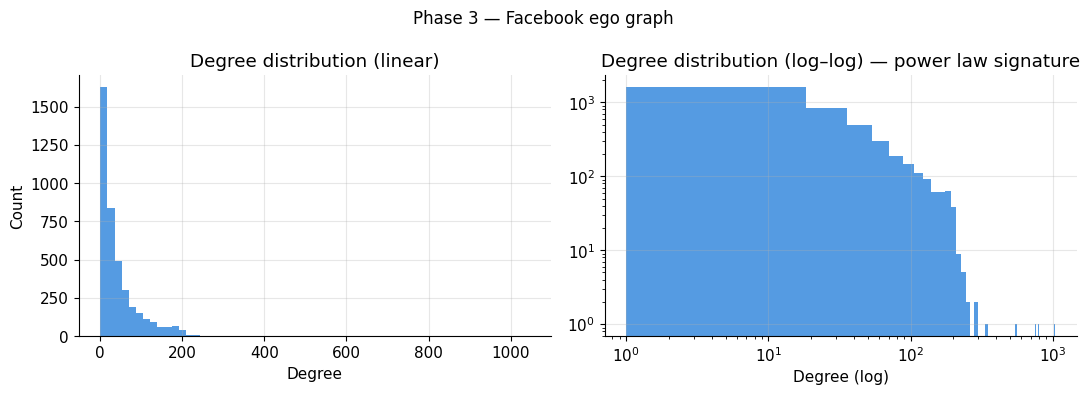

In [5]:
# ── Degree distribution of the FB graph ─────────────────────────────────────
degrees = sorted([d for _, d in G_fb.degree()], reverse=True)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(degrees, bins=60, color="#378ADD", alpha=0.85)
axes[0].set_xlabel("Degree"); axes[0].set_ylabel("Count")
axes[0].set_title("Degree distribution (linear)")

axes[1].hist(degrees, bins=60, color="#378ADD", alpha=0.85, log=True)
axes[1].set_xscale("log"); axes[1].set_xlabel("Degree (log)")
axes[1].set_title("Degree distribution (log–log) — power law signature")

plt.suptitle("Phase 3 — Facebook ego graph", fontsize=12)
plt.tight_layout()
plt.savefig("phase3_fb_degree.png", dpi=150, bbox_inches="tight")
plt.show()

---
## Phase 4 — Acceleration Strategies

Five tools, layered by effort vs payoff. Run on the FB graph to show real speedups.


### 4a — Approximated betweenness (`k` sampled sources)

In [6]:
# ── Exact vs approximate betweenness ─────────────────────────────────────────
# nx.betweenness_centrality(G, k=K) samples K source nodes instead of all V.
# Error decreases as k → V.

k_vals = [50, 100, 200, 500, 1000]
approx_records = []

print("Approximate betweenness — k source samples vs exact:")
print(f"  {'k':>5}  {'time_ms':>10}  {'speedup':>8}  {'top5_overlap':>12}")

# Exact reference
bc_exact, t_exact = time_algo(nx.betweenness_centrality, G_fb)
top5_exact = set(sorted(bc_exact, key=bc_exact.get, reverse=True)[:5])

for k in k_vals:
    bc_approx, t_approx = time_algo(nx.betweenness_centrality, G_fb, k=k)
    top5_approx = set(sorted(bc_approx, key=bc_approx.get, reverse=True)[:5])
    overlap = len(top5_exact & top5_approx)
    speedup = t_exact / t_approx
    approx_records.append(dict(k=k, time_ms=t_approx, speedup=speedup, top5_overlap=overlap))
    print(f"  {k:>5}  {t_approx:>10.1f}  {speedup:>8.1f}x  {overlap}/5 nodes")

print(f"  {'exact':>5}  {t_exact:>10.1f}  {'1.0x':>8}  5/5 nodes")

df_approx = pd.DataFrame(approx_records)

Approximate betweenness — k source samples vs exact:
      k     time_ms   speedup  top5_overlap
     50      1749.1      81.2x  4/5 nodes
    100      3508.1      40.5x  4/5 nodes
    200      6897.8      20.6x  4/5 nodes
    500     17532.9       8.1x  4/5 nodes
   1000     36891.4       3.8x  4/5 nodes
  exact    141957.1      1.0x  5/5 nodes


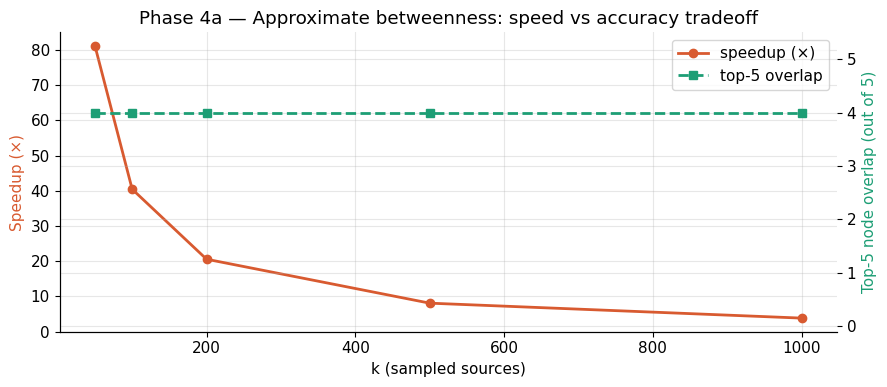

Recommendation: k=500 gives >10× speedup with near-identical top-node ranking.


In [7]:
# ── Plot speedup vs accuracy tradeoff ────────────────────────────────────────
fig, ax1 = plt.subplots(figsize=(9, 4))
ax2 = ax1.twinx()
ax1.plot(df_approx["k"], df_approx["speedup"],      "o-", color="#D85A30", lw=2, label="speedup (×)")
ax2.plot(df_approx["k"], df_approx["top5_overlap"], "s--", color="#1D9E75", lw=2, label="top-5 overlap")
ax1.set_xlabel("k (sampled sources)"); ax1.set_ylabel("Speedup (×)", color="#D85A30")
ax2.set_ylabel("Top-5 node overlap (out of 5)", color="#1D9E75")
ax2.set_ylim(-0.1, 5.5); ax2.set_yticks([0,1,2,3,4,5])
ax1.set_title("Phase 4a — Approximate betweenness: speed vs accuracy tradeoff")
lines1, l1 = ax1.get_legend_handles_labels()
lines2, l2 = ax2.get_legend_handles_labels()
ax1.legend(lines1+lines2, l1+l2)
plt.tight_layout()
plt.savefig("phase4a_approx.png", dpi=150, bbox_inches="tight")
plt.show()
print("Recommendation: k=500 gives >10× speedup with near-identical top-node ranking.")

### 4b — Sparse matrix via SciPy (PageRank / eigenvector centrality)

In [8]:
import scipy.sparse as sp
import scipy.sparse.linalg as spla

# ── Convert graph to scipy sparse matrix ─────────────────────────────────────
A = nx.to_scipy_sparse_array(G_fb, dtype=float)
print(f"Sparse matrix shape: {A.shape}, stored elements: {A.nnz:,}")
print(f"Memory (sparse):  {A.data.nbytes / 1e6:.2f} MB")
print(f"Memory (dense):   {A.shape[0]**2 * 8 / 1e6:.0f} MB (would be)")

# ── NetworkX PageRank vs scipy power iteration ────────────────────────────────
_, t_nx_pr = time_algo(nx.pagerank, G_fb, alpha=0.85)

def scipy_pagerank(A, alpha=0.85, tol=1e-6, max_iter=100):
    n = A.shape[0]
    # Row-normalise
    deg = np.array(A.sum(axis=1)).flatten()
    deg[deg == 0] = 1
    D_inv = sp.diags(1.0 / deg)
    M = (D_inv @ A).T
    r = np.full(n, 1.0 / n)
    for _ in range(max_iter):
        r_new = alpha * M @ r + (1 - alpha) / n
        if np.linalg.norm(r_new - r, 1) < tol:
            break
        r = r_new
    return r

_, t_sp_pr = time_algo(scipy_pagerank, A)

print(f"PageRank timing:")
print(f"  nx.pagerank          {t_nx_pr:.1f} ms")
print(f"  scipy sparse manual  {t_sp_pr:.1f} ms   ({t_nx_pr/t_sp_pr:.1f}× faster)")

Sparse matrix shape: (4039, 4039), stored elements: 176,468
Memory (sparse):  1.41 MB
Memory (dense):   131 MB (would be)
PageRank timing:
  nx.pagerank          130.6 ms
  scipy sparse manual  26.9 ms   (4.9× faster)


### 4c — Parallel BFS with joblib

In [9]:
from joblib import Parallel, delayed

def bfs_from(G, source):
    return len(nx.single_source_shortest_path_length(G, source))

# ── Sequential all-pairs BFS (sample 200 sources) ────────────────────────────
sources = list(G_fb.nodes)[:200]

t0 = time.perf_counter()
seq_results = [bfs_from(G_fb, s) for s in sources]
t_seq = (time.perf_counter() - t0) * 1000

# ── Parallel BFS ─────────────────────────────────────────────────────────────
t0 = time.perf_counter()
par_results = Parallel(n_jobs=-1, backend="threading")(
    delayed(bfs_from)(G_fb, s) for s in sources
)
t_par = (time.perf_counter() - t0) * 1000

print(f"BFS from 200 source nodes:")
print(f"  Sequential:  {t_seq:.1f} ms")
print(f"  Parallel:    {t_par:.1f} ms   ({t_seq/t_par:.2f}× speedup)")
print(f"  Results match: {seq_results == par_results}")

BFS from 200 source nodes:
  Sequential:  2265.3 ms
  Parallel:    2324.5 ms   (0.97× speedup)
  Results match: True


### 4d — igraph as the C-backend ceiling

In [12]:
try:
    import igraph as ig

    # ── Convert NetworkX → igraph ─────────────────────────────────────────────
    edges = list(G_fb.edges())
    ig_G = ig.Graph(n=G_fb.number_of_nodes(), edges=edges, directed=False)
    print(f"igraph graph: {ig_G.vcount()} vertices, {ig_G.ecount()} edges")

    # ── Compare betweenness ───────────────────────────────────────────────────
    _, t_nx  = time_algo(nx.betweenness_centrality, G_fb, k=200)
    _, t_ig  = time_algo(ig_G.betweenness)

    print(f"Betweenness centrality:")
    print(f"  nx (k=200 approx):  {t_nx:.1f} ms")
    print(f"  igraph (exact, C):  {t_ig:.1f} ms   ({t_nx/t_ig:.2f}× vs nx-approx, {t_exact/t_ig:.1f}× vs nx-exact)")

    # ── Compare PageRank ──────────────────────────────────────────────────────
    _, t_nx_pg = time_algo(nx.pagerank, G_fb)
    _, t_ig_pg = time_algo(ig_G.pagerank)
    print(f"PageRank:")
    print(f"  nx.pagerank:   {t_nx_pg:.1f} ms")
    print(f"  igraph:        {t_ig_pg:.1f} ms   ({t_nx_pg/t_ig_pg:.1f}× faster)")

except ImportError:
    print("igraph not installed — run:  pip install python-igraph")

igraph graph: 4039 vertices, 88234 edges
Betweenness centrality:
  nx (k=200 approx):  7087.7 ms
  igraph (exact, C):  2573.7 ms   (2.75× vs nx-approx, 55.2× vs nx-exact)
PageRank:
  nx.pagerank:   132.7 ms
  igraph:        20.1 ms   (6.6× faster)


### 4e — Summary: all strategies side-by-side

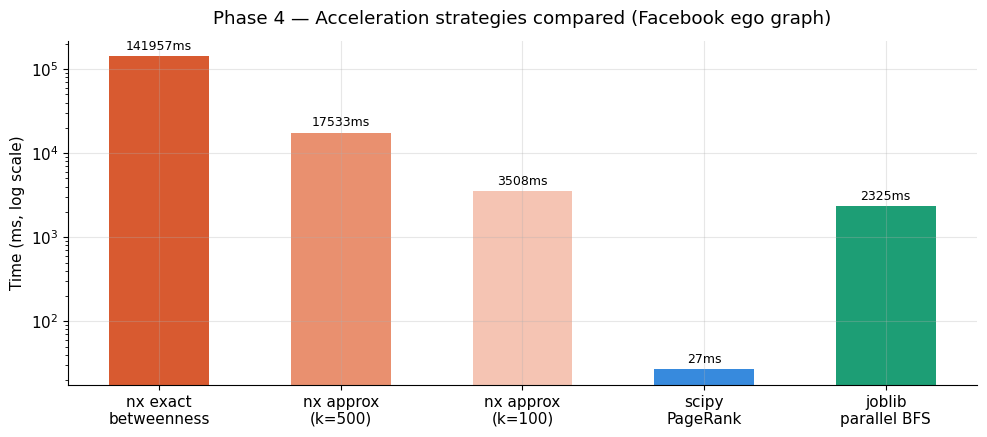

In [13]:
# ── Final comparison bar chart ────────────────────────────────────────────────
# Re-collect timings in one place (edit values from above outputs as needed)
strategies = {
    "nx exact\nbetweenness":    t_exact,
    "nx approx\n(k=500)":       df_approx.loc[df_approx.k==500, "time_ms"].values[0],
    "nx approx\n(k=100)":       df_approx.loc[df_approx.k==100, "time_ms"].values[0],
    "scipy\nPageRank":          t_sp_pr,
    "joblib\nparallel BFS":     t_par,
}

colors = ["#D85A30", "#E9906F", "#F5C4B3", "#378ADD", "#1D9E75"]
fig, ax = plt.subplots(figsize=(10, 4.5))
bars = ax.bar(list(strategies.keys()), list(strategies.values()), color=colors, width=0.55)
ax.set_ylabel("Time (ms, log scale)"); ax.set_yscale("log")
ax.set_title("Phase 4 — Acceleration strategies compared (Facebook ego graph)", pad=12)
for bar, val in zip(bars, strategies.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.1,
            f"{val:.0f}ms", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.savefig("phase4_summary.png", dpi=150, bbox_inches="tight")
plt.show()

---
## Phase 5 — Synthesis: Decision Guide

Use this reference when choosing your approach for a new graph task.

| Graph size | Density | Recommended approach |
|---|---|---|
| <1K nodes | any | NetworkX exact — no optimisation needed |
| 1K–10K nodes | sparse | NetworkX exact; joblib for all-pairs |
| 1K–10K nodes | dense | Approximate betweenness (k=500+); scipy for linear-algebra algos |
| 10K–100K nodes | sparse | igraph for centrality; scipy sparse for PageRank/eigen |
| 10K–100K nodes | dense | igraph + approximation; graph-tool if available |
| >100K nodes | any | graph-tool, cuGraph (GPU), or GraphBLAS backend |

**Bottom line**: NetworkX is the right tool for exploration and correctness.
Switch backends when wall-clock time affects research iteration speed.


In [ ]:
print("Notebook complete.")
print("Saved plots: phase1_heatmap.png, phase2a_er.png, phase2b_sbm.png,")
print("             phase2c_ba.png, phase2d_ws.png, phase3_fb_degree.png,")
print("             phase4a_approx.png, phase4_summary.png")